# Section 4 figures and coverage numbers for the kick-off report

Generates the five Section 4 figures of `notes/Project_Big_Data.md`, applies the coverage rule of report Section 5.1, and prints the numbers quoted in Section 4 of the report (the counts `X`, `Y`, `X2`, `Y2`, the ACORN tests, the London-time load profile, the kWh quartiles `Q1`, `MEDIAN`, `Q3`, the counts of High / Low / Normal trial days and their household-days, and the supporting checks in Step 9).

| Figure | Output file | What it shows |
|---|---|---|
| 4.2 | `fig4_2_coverage.png` | Households reporting per month, Std vs ToU |
| 4.3 | `fig4_3_incomplete_days.png` | % of household-days with fewer than 48 readings, split into first/last days and all other days |
| 4.6 | `fig4_6_acorn_tariff.png` | dToU share by ACORN group, household-level chi-square and block-level permutation test |
| 4.7 | `fig4_7_load_profile.png` | Mean demand by time of day on the London clock, with the evening peak band |
| 4.8 | `fig4_8_kwh_hist.png` | Half-hourly kWh histogram (10% of households from every block) |

Other outputs in `OUT_DIR`: `numbers_for_report.txt` (every number the report quotes from this notebook) and `household_coverage_flags.csv` (one row per household with its coverage flags, so the report's counts can be traced to households). These two files are tracked in git; the PNGs are not.

## How to use
1. **Step 1:** if the dataset is already on this computer, put its folder in `DATA_DIR`. Leave it as `None` to use the kagglehub cache (downloads the dataset the first time; needs a Kaggle API token). `OUT_DIR` sets where the outputs are saved.
2. **Step 2 only checks the environment.** It never installs or upgrades anything: newer numpy and matplotlib builds can be blocked by Windows Application Control, so the versions in `requirements.txt` are pinned on purpose. If a package is too old or missing, the cell stops and says how to install it.
3. **Restart the kernel, then Run All.**
4. Check the figures in `OUT_DIR` against the report, and copy any changed numbers from `numbers_for_report.txt` into Section 4 of `notes/Project_Big_Data.md`.

Runtime: Steps 4 and 5 take about a minute. Steps 6 and 8 each read all 112 half-hourly files one at a time, and Step 7 reads the 112 hhblock files (a few minutes in total, low memory). Step 9 reloads the daily layer once more. Step 8 needs `Tariffs.xlsx`; run Section 0b of `01_eda_smart_meters.ipynb` first if `~/.cache/london_datastore/` is empty.

## Step 1: Settings

In [1]:
# Folder that contains informations_households.csv (a parent folder also works).
# Example: DATA_DIR = r"D:\data\smart-meters-in-london"
DATA_DIR = None

# Where the PNGs, numbers_for_report.txt and household_coverage_flags.csv are written. A relative path
# is resolved against the notebook's working directory (normally the folder the notebook is in).
OUT_DIR = "../outputs"

SAMPLE_FRAC = 0.10   # share of households per block file used for Fig 4.8
SEED = 431

# Coverage rule, report Section 5.1
USABLE_READINGS = 44         # a day is usable with at least this many of its 48 half-hourly readings
COVERAGE_MIN = 0.90          # share of usable days needed: over a household's own 2013 period, and within a 2012 month
MIN_USABLE_MONTHS_2012 = 6   # usable 2012 months needed for the year-over-year subset

# Diagnostics only: neither changes the rule or the counts above.
SHORT_SPAN_DAYS_2013 = 300   # 2013 periods shorter than this are counted separately (see below)
MONTH_SENSITIVITY = 0.50     # alternative usable-month threshold, to show how much the 2012 count depends on it

## Step 2: Environment check

NumPy 2.x needs **matplotlib >= 3.9** and **pandas >= 2.2.2**. This cell only checks; it does not install anything. `requirements.txt` pins numpy and matplotlib below their latest releases because newer builds can be blocked by Windows Application Control (the import then fails with "An Application Control policy has blocked this file"), and an automatic upgrade would replace a working pin with a blocked build.

In [2]:
import os
import re
import sys
from importlib.metadata import PackageNotFoundError, version


def installed(pkg):
    try:
        return version(pkg)
    except PackageNotFoundError:
        return None


def older_than(pkg, minimum):
    v = installed(pkg)
    if v is None:
        return True
    nums = tuple(int(m.group()) for part in v.split(".")[:3] if (m := re.match(r"\d+", part)))
    return nums < minimum


needs = [spec for pkg, minimum, spec in [("matplotlib", (3, 9), "matplotlib>=3.9"),
                                         ("pandas", (2, 2, 2), "pandas>=2.2.2")]
         if older_than(pkg, minimum)]
if DATA_DIR is None and not os.environ.get("SMART_METER_DIR") and installed("kagglehub") is None:
    needs.append("kagglehub")

print("Python:", sys.executable)
for pkg in ["numpy", "pandas", "matplotlib", "kagglehub"]:
    print(f"  {pkg:<11} {installed(pkg) or 'not installed'}")

if needs:
    raise RuntimeError(f"Missing or too old: {', '.join(needs)}. Install the versions in requirements.txt "
                       f"(for uv: uv pip install --python \"{sys.executable}\" -r requirements.txt), "
                       "then restart the kernel and Run All again. Do not install the latest numpy or "
                       "matplotlib without importing them first: Windows Application Control may block them.")
print("\nAll packages OK.")

Python: <project>\.venv\Scripts\python.exe
  numpy       2.2.6
  pandas      3.0.5
  matplotlib  3.10.0
  kagglehub   1.0.2

All packages OK.


In [3]:
import importlib

importlib.invalidate_caches()
try:
    import math
    from pathlib import Path

    import matplotlib.pyplot as plt
    import numpy as np
    import numpy.random  # noqa: F401  (numpy 2.x loads this lazily, so a blocked build only fails here)
    import pandas as pd
except (ImportError, AttributeError) as err:
    if "Application Control" in str(err):
        hint = ("A Windows Application Control policy blocked a native library file, so a restart will not "
                "help. Install an older numpy / matplotlib build (see requirements.txt), then restart.")
    else:
        hint = "Restart the kernel, then Run All again."
    raise RuntimeError(f"Import failed. {hint} Original error: {err}") from err

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {plt.matplotlib.__version__}")

STD, TOU = "#5B7C99", "#E07A3F"
EDGE = "#B8B8B8"  # first/last household day in Fig 4.3
GROUPS = ["Affluent", "Comfortable", "Adversity"]
GROUP_COL = {"Affluent": "#3A7D44", "Comfortable": "#D9A441", "Adversity": "#B5473A"}
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 11})

numpy 2.2.6 | pandas 3.0.5 | matplotlib 3.10.0


## Step 3: Load dataset

In [4]:
def resolve_dataset_dir():
    source = DATA_DIR or os.environ.get("SMART_METER_DIR")
    if source:
        root = Path(source).expanduser()
        if not root.exists():
            raise FileNotFoundError(f"DATA_DIR does not exist: {root}")
    else:
        import kagglehub
        root = Path(kagglehub.dataset_download("jeanmidev/smart-meters-in-london"))
    if (root / "informations_households.csv").exists():
        return root
    hits = sorted(root.rglob("informations_households.csv"))
    if not hits:
        raise FileNotFoundError(f"informations_households.csv not found anywhere under {root}")
    return hits[0].parent


dataset_dir = resolve_dataset_dir()
OUT = Path(OUT_DIR).expanduser()
OUT.mkdir(parents=True, exist_ok=True)
report = {}  # values for the yellow blanks in the report

households = pd.read_csv(dataset_dir / "informations_households.csv")
print(f"Dataset directory: {dataset_dir}")
print(f"Households: {len(households):,}")
print(f"Figures will be saved to: {OUT.resolve()}")

Dataset directory: ~\.cache\kagglehub\datasets\jeanmidev\smart-meters-in-london\versions\21
Households: 5,566
Figures will be saved to: <project>\outputs


## Step 4: Daily layer, coverage and incomplete days (Figs 4.2, 4.3)

In [5]:
cols = ["LCLid", "day", "energy_count"]
daily_csv = dataset_dir / "daily_dataset.csv"
if daily_csv.exists():
    daily = pd.read_csv(daily_csv, usecols=cols)
else:  # fall back to the 112 block files
    daily = pd.concat([pd.read_csv(f, usecols=cols)
                       for f in sorted((dataset_dir / "daily_dataset").rglob("block_*.csv"))],
                      ignore_index=True)
daily["day"] = pd.to_datetime(daily["day"])
daily = daily.merge(households[["LCLid", "stdorToU"]], on="LCLid", how="left")
daily["month"] = daily["day"].dt.to_period("M").dt.to_timestamp()
print(f"{len(daily):,} household-days, {daily['day'].min():%d %b %Y} to {daily['day'].max():%d %b %Y}")

3,510,433 household-days, 23 Nov 2011 to 28 Feb 2014


### Fig 4.2 Households reporting per month

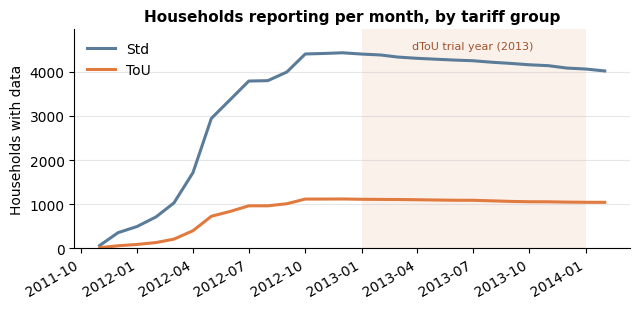

In [6]:
coverage = (daily.groupby(["month", "stdorToU"])["LCLid"].nunique()
            .unstack("stdorToU").reindex(columns=["Std", "ToU"]).fillna(0))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.axvspan(pd.Timestamp("2013-01-01"), pd.Timestamp("2014-01-01"), color=TOU, alpha=0.10, lw=0)
ax.plot(coverage.index, coverage["Std"], color=STD, lw=2.2, label="Std")
ax.plot(coverage.index, coverage["ToU"], color=TOU, lw=2.2, label="ToU")
ax.text(pd.Timestamp("2013-07-01"), coverage.values.max() * 1.02, "dToU trial year (2013)",
        ha="center", fontsize=8, color="#A0522D")
ax.set_ylim(0, coverage.values.max() * 1.12)
ax.set_ylabel("Households with data")
ax.set_title("Households reporting per month, by tariff group")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "fig4_2_coverage.png", dpi=200)
plt.show()

### Fig 4.3 Household-days with fewer than 48 readings

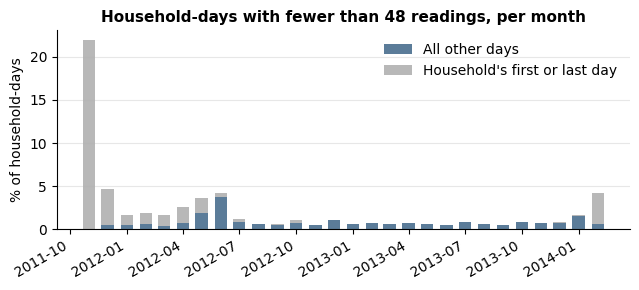

Incomplete household-days: 41,081 of 3,510,433 (1.17%)
  on a household's first or last day: 11,018 (26.8% of incomplete days)
  on all other days: 30,063 (0.86% of those 3,499,306 days)
Household-days with 0 readings: 30
Worst month, all days: Nov 2011 (22.0%) (partial start-up month, 346 household-days)
Worst month, excluding first/last days: Jun 2012 (3.75%)
Five worst days, excluding first/last days (% of households reporting that day):
day
2012-06-13    18.7%
2012-06-14    19.6%
2012-06-15    21.2%
2012-06-16    23.1%
2012-06-17    19.8%


Calendar days absent inside households' reporting spans: 4,088 (households with a gap: 733)


In [7]:
# A household's first and last day are partial by construction (metering starts or stops mid-day),
# so they are split out from days that are incomplete for other reasons.
daily["incomplete"] = daily["energy_count"] < 48
first_day = daily.groupby("LCLid")["day"].transform("min")
last_day = daily.groupby("LCLid")["day"].transform("max")
daily["edge_day"] = (daily["day"] == first_day) | (daily["day"] == last_day)
daily["inc_edge"] = daily["incomplete"] & daily["edge_day"]
daily["inc_inner"] = daily["incomplete"] & ~daily["edge_day"]
pct = daily.groupby("month")[["inc_inner", "inc_edge"]].mean() * 100

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.bar(pct.index, pct["inc_inner"], width=20, color=STD, label="All other days")
ax.bar(pct.index, pct["inc_edge"], width=20, bottom=pct["inc_inner"], color=EDGE,
       label="Household's first or last day")
ax.set_ylabel("% of household-days")
ax.set_title("Household-days with fewer than 48 readings, per month")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "fig4_3_incomplete_days.png", dpi=200)
plt.show()

n_incomplete = int(daily["incomplete"].sum())
n_edge = int(daily["inc_edge"].sum())
n_inner = int(daily["inc_inner"].sum())
n_inner_days = int((~daily["edge_day"]).sum())
n_zero = int((daily["energy_count"] == 0).sum())
print(f"Incomplete household-days: {n_incomplete:,} of {len(daily):,} ({n_incomplete / len(daily):.2%})")
print(f"  on a household's first or last day: {n_edge:,} ({n_edge / n_incomplete:.1%} of incomplete days)")
print(f"  on all other days: {n_inner:,} ({n_inner / n_inner_days:.2%} of those {n_inner_days:,} days)")
print(f"Household-days with 0 readings: {n_zero:,}")

total_pct = pct.sum(axis=1)
print(f"Worst month, all days: {total_pct.idxmax():%b %Y} ({total_pct.max():.1f}%)"
      f" (partial start-up month, {int((daily['month'] == total_pct.idxmax()).sum()):,} household-days)")
print(f"Worst month, excluding first/last days: {pct['inc_inner'].idxmax():%b %Y} ({pct['inc_inner'].max():.2f}%)")

inner_days = daily[~daily["edge_day"]].groupby("day")["incomplete"].mean() * 100
print("Five worst days, excluding first/last days (% of households reporting that day):")
print(inner_days.nlargest(5).sort_index().map("{:.1f}%".format).to_string())

# Missing rows are invisible to the figure above (it only counts days that exist).
gaps = daily.sort_values(["LCLid", "day"]).groupby("LCLid")["day"].diff().dt.days - 1
print(f"Calendar days absent inside households' reporting spans: {int(gaps.clip(lower=0).sum()):,}"
      f" (households with a gap: {int(daily.loc[gaps[gaps > 0].index, 'LCLid'].nunique()):,})")

### Coverage rule from report Section 5.1 (fills `X`, `Y`, `X2`, `Y2`)

A day is usable with at least 44 of its 48 half-hourly readings. A calendar day with no row in the daily layer counts as unusable.

- **2013 (`X2`, `Y2`):** at least 90% of the calendar days in the household's own recorded period within 2013 (first to last record day, clipped to 2013) are usable. Households recruited after 1 January 2012, or that stopped reporting during 2013, are not penalised for days outside their own period.
- **Both years (`X`, `Y`):** the 2013 rule plus at least 6 usable months in 2012. The report does not define a usable month; here it is a month in which at least 90% of the calendar days are usable, matching the other thresholds.

Two diagnostics are printed with the numbers for the report. Neither changes the counts:
- **Month threshold:** the both-years counts if a usable month needed only 50% of its days.
- **Short 2013 periods:** the rule has no minimum length, so a household recorded for only a few weeks of 2013 passes on those weeks alone. The diagnostic counts how many passing households have a recorded 2013 period under 300 days.

`household_coverage_flags.csv` saves each household's flags and the values behind them.

In [8]:
daily["usable"] = daily["energy_count"] >= USABLE_READINGS
span = daily.groupby("LCLid")["day"].agg(start="min", end="max")

# 2013: usable days over the calendar days of the household's own recorded period inside 2013.
start_2013 = span["start"].clip(lower=pd.Timestamp("2013-01-01"))
end_2013 = span["end"].clip(upper=pd.Timestamp("2013-12-31"))
days_2013 = ((end_2013 - start_2013).dt.days + 1).clip(lower=0)  # 0 when the household has no 2013 period
usable_2013 = (daily[daily["day"].dt.year == 2013].groupby("LCLid")["usable"].sum()
               .reindex(span.index).fillna(0))
ok_2013 = usable_2013 / days_2013.where(days_2013 > 0) >= COVERAGE_MIN

# 2012: a month is usable when at least COVERAGE_MIN of its calendar days are usable.
in_2012 = daily[daily["day"].dt.year == 2012]
usable_days_2012 = (in_2012.groupby(["LCLid", in_2012["day"].dt.month])["usable"].sum()
                    .unstack().reindex(columns=range(1, 13)).fillna(0))
days_in_month = pd.Series([pd.Period(f"2012-{m:02d}").days_in_month for m in range(1, 13)],
                          index=range(1, 13))
usable_months_2012 = ((usable_days_2012 / days_in_month) >= COVERAGE_MIN).sum(axis=1).reindex(span.index).fillna(0)
ok_both = ok_2013 & (usable_months_2012 >= MIN_USABLE_MONTHS_2012)

# Diagnostics: the same counts under a looser month threshold. The rule itself is unchanged.
months_alt = ((usable_days_2012 / days_in_month) >= MONTH_SENSITIVITY).sum(axis=1).reindex(span.index).fillna(0)
ok_both_alt = ok_2013 & (months_alt >= MIN_USABLE_MONTHS_2012)

# One row per household, saved so the report's counts can be traced to households.
hid = pd.Index(households["LCLid"], name="LCLid")
flags = pd.DataFrame({
    "stdorToU": households.set_index("LCLid")["stdorToU"],
    "days_in_2013_period": days_2013.reindex(hid).fillna(0).astype(int),
    "usable_days_2013": usable_2013.reindex(hid).fillna(0).astype(int),
    "usable_months_2012": usable_months_2012.reindex(hid).fillna(0).astype(int),
    "ok_2013": ok_2013.reindex(hid).fillna(False).astype(bool),
    "ok_both": ok_both.reindex(hid).fillna(False).astype(bool),
    "ok_both_alt_month_rule": ok_both_alt.reindex(hid).fillna(False).astype(bool),
})
flags.reset_index().to_csv(OUT / "household_coverage_flags.csv", index=False, lineterminator="\n")

counts = flags.groupby("stdorToU")[["ok_both", "ok_2013"]].sum().astype(int)
counts["total"] = households["stdorToU"].value_counts()
alt = flags.groupby("stdorToU")["ok_both_alt_month_rule"].sum().astype(int)

# The report's 2013 rule has no minimum length: a household recorded for a short part of 2013 passes on that part alone.
short = flags[flags["ok_2013"] & (flags["days_in_2013_period"] < SHORT_SPAN_DAYS_2013)]
n_short = short.groupby("stdorToU").size().reindex(["Std", "ToU"]).fillna(0).astype(int)

report["X  (Std, both 2012 and 2013)"] = int(counts.loc["Std", "ok_both"])
report["Y  (ToU, both 2012 and 2013)"] = int(counts.loc["ToU", "ok_both"])
report["X2 (Std, 2013)"] = int(counts.loc["Std", "ok_2013"])
report["Y2 (ToU, 2013)"] = int(counts.loc["ToU", "ok_2013"])
report["Usable-month rule (2012)"] = (f">= {COVERAGE_MIN:.0%} of calendar days usable (>= {USABLE_READINGS}/48 readings); "
                                      f">= {MIN_USABLE_MONTHS_2012} such months")
report["Sensitivity (2012 month)"] = (f"usable month at >= {MONTH_SENSITIVITY:.0%} of days instead: "
                                      f"{alt['Std']:,} Std, {alt['ToU']:,} ToU with both years")
report["Short 2013 periods"] = (f"{n_short['Std']:,} Std and {n_short['ToU']:,} ToU households pass the 2013 rule "
                                f"with a recorded 2013 period under {SHORT_SPAN_DAYS_2013} days "
                                f"(shortest {int(short['days_in_2013_period'].min())} days)")
counts


,ok_both,ok_2013,total
stdorToU,,,
Std,3356,4387,4443
ToU,835,1111,1123


In [9]:
del daily, in_2012, usable_days_2012, flags  # free memory before Step 6

## Step 5: Fig 4.6 dToU share by ACORN group

Recomputes the household-level chi-square test from the report's Section 6 so the two sections agree. The 51 unclassified households (ACORN-U or blank) are excluded.

That test treats every household as an independent draw. The data does not support this: block files hold one ACORN group each (almost always) and the dToU share varies between blocks far more than chance allows. A second test therefore uses each block file as one unit (permutation test, group labels shuffled across blocks). Both results are reported; the block-level one is the more cautious.

109 single-group blocks of 111 (Affluent 43, Comfortable 30, Adversity 36)
Spread of dToU share between blocks: sd 15.9 points observed, 5.7 expected if households were independent
Mean block dToU share: Affluent 21.9%, Comfortable 21.5%, Adversity 16.4%
Block-level permutation test, three groups: p = 0.267
Block-level permutation test, Adversity vs the other two (-5.3 points): p = 0.107


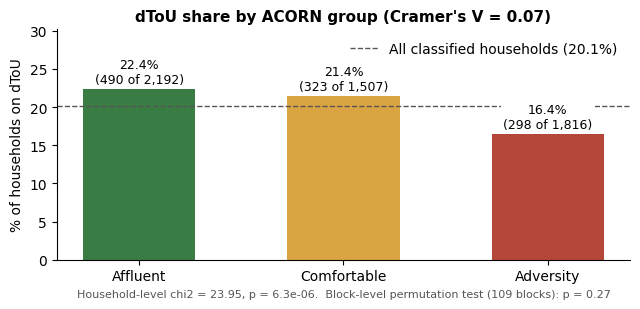

stdorToU,Std,ToU
Acorn_grouped,,
Affluent,1702,490
Comfortable,1184,323
Adversity,1518,298


In [10]:
classified = households[households["Acorn_grouped"].isin(GROUPS)]
n_unclassified = len(households) - len(classified)
table = pd.crosstab(classified["Acorn_grouped"], classified["stdorToU"]).reindex(GROUPS)
n_classified = int(table.values.sum())
expected_counts = np.outer(table.sum(axis=1), table.sum(axis=0)) / n_classified
chi2 = float(((table.values - expected_counts) ** 2 / expected_counts).sum())
dof = (table.shape[0] - 1) * (table.shape[1] - 1)
assert dof == 2, "the p-value shortcut below is exact only for df = 2"
p_value = math.exp(-chi2 / 2)  # chi-square survival function for df = 2
cramers_v = math.sqrt(chi2 / n_classified)  # min(rows - 1, cols - 1) = 1 for a 3 x 2 table
share = table["ToU"] / table.sum(axis=1) * 100
overall = table["ToU"].sum() / n_classified * 100

# Block-level check: one observation per block file instead of per household.
# Blocks that mix ACORN groups cannot be assigned to a group, so they are left out.
blocks = (classified.assign(tou=classified["stdorToU"].eq("ToU"))
          .groupby("file").agg(n=("tou", "size"), tou=("tou", "mean"),
                               n_groups=("Acorn_grouped", "nunique"),
                               group=("Acorn_grouped", lambda s: s.mode()[0])))
blocks = blocks[blocks["n_groups"] == 1]
tou_block = blocks["tou"].to_numpy()
code = blocks["group"].map({g: i for i, g in enumerate(GROUPS)}).to_numpy()
p_all = table["ToU"].sum() / n_classified
sd_observed = tou_block.std(ddof=1) * 100
sd_expected = math.sqrt((p_all * (1 - p_all) / blocks["n"]).mean()) * 100  # if households were independent


def between_group_ss(c):
    counts = np.bincount(c, minlength=len(GROUPS))
    sums = np.bincount(c, weights=tou_block, minlength=len(GROUPS))
    return float((counts * (sums / counts - tou_block.mean()) ** 2).sum())


N_PERM = 20_000
rng = np.random.default_rng(SEED)
observed_ss = between_group_ss(code)
perm_ss = np.array([between_group_ss(rng.permutation(code)) for _ in range(N_PERM)])
p_block = (1 + int((perm_ss >= observed_ss).sum())) / (N_PERM + 1)
adv = code == GROUPS.index("Adversity")
diff_adv = tou_block[adv].mean() - tou_block[~adv].mean()
perm_diff = np.array([(lambda a: tou_block[a].mean() - tou_block[~a].mean())(rng.permutation(adv))
                      for _ in range(N_PERM)])
p_block_adv = (1 + int((np.abs(perm_diff) >= abs(diff_adv)).sum())) / (N_PERM + 1)
block_mean = blocks.groupby("group")["tou"].mean().reindex(GROUPS) * 100
print(f"{len(blocks)} single-group blocks of {classified['file'].nunique()} "
      f"({', '.join(f'{g} {int((blocks.group == g).sum())}' for g in GROUPS)})")
print(f"Spread of dToU share between blocks: sd {sd_observed:.1f} points observed, "
      f"{sd_expected:.1f} expected if households were independent")
print("Mean block dToU share: " + ", ".join(f"{g} {block_mean[g]:.1f}%" for g in GROUPS))
print(f"Block-level permutation test, three groups: p = {p_block:.3f}")
print(f"Block-level permutation test, Adversity vs the other two ({diff_adv * 100:+.1f} points): "
      f"p = {p_block_adv:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
bars = ax.bar(GROUPS, share.values, color=[GROUP_COL[g] for g in GROUPS], width=0.55)
ax.axhline(overall, color="#555", ls="--", lw=1, zorder=1, label=f"All classified households ({overall:.1f}%)")
for bar, g in zip(bars, GROUPS):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{share[g]:.1f}%\n({table.loc[g, 'ToU']:,} of {table.loc[g].sum():,})",
            ha="center", va="bottom", fontsize=9, zorder=3,
            bbox={"fc": "white", "ec": "none", "pad": 1.5})  # keeps the dashed line off the labels
ax.set_ylim(0, share.max() * 1.35)
ax.set_ylabel("% of households on dToU")
ax.set_title(f"dToU share by ACORN group (Cramer's V = {cramers_v:.2f})")
ax.set_xlabel(f"Household-level chi2 = {chi2:.2f}, p = {p_value:.1e}.  "
              f"Block-level permutation test ({len(blocks)} blocks): p = {p_block:.2f}",
              fontsize=8, color="#555")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(OUT / "fig4_6_acorn_tariff.png", dpi=200)
plt.show()

report["chi-square check"] = (", ".join(f"{g} {share[g]:.1f}% ToU" for g in GROUPS)
                              + f"; household-level chi2 = {chi2:.2f}, df = 2, p = {p_value:.2e}"
                              + f", Cramer's V = {cramers_v:.3f}")
report["block-level test"] = (f"{len(blocks)} blocks, mean block dToU share "
                              + ", ".join(f"{g} {block_mean[g]:.1f}%" for g in GROUPS)
                              + f"; permutation p = {p_block:.3f} (three groups), "
                              f"{p_block_adv:.3f} (Adversity vs others)")
report["ACORN unclassified (excluded)"] = n_unclassified
table

## Step 6: Fig 4.8 Half-hourly kWh distribution (fills `Q1`, `MEDIAN`, `Q3`)

Samples 10% of households **from every block file**. Block files group households by ACORN category, so a single block (like `block_0`) is not representative.

In [11]:
sample_ids = set(households.groupby("file", group_keys=False)
                 .sample(frac=SAMPLE_FRAC, random_state=SEED)["LCLid"])
block_files = sorted((dataset_dir / "halfhourly_dataset").rglob("block_*.csv"))
if not block_files:
    raise FileNotFoundError(f"No block_*.csv files under {dataset_dir / 'halfhourly_dataset'}")
print(f"{len(sample_ids):,} sampled households, {len(block_files)} block files")

chunks = []
for i, path in enumerate(block_files, 1):
    block = pd.read_csv(path, usecols=["LCLid", "energy(kWh/hh)"], na_values=["Null"])
    values = block.loc[block["LCLid"].isin(sample_ids), "energy(kWh/hh)"].dropna()
    chunks.append(values.to_numpy(dtype="float32"))
    if i % 16 == 0 or i == len(block_files):
        print(f"  read {i}/{len(block_files)} block files")
kwh = pd.Series(np.concatenate(chunks))
del chunks, block

557 sampled households, 112 block files


  read 16/112 block files


  read 32/112 block files


  read 48/112 block files


  read 64/112 block files


  read 80/112 block files


  read 96/112 block files


  read 112/112 block files


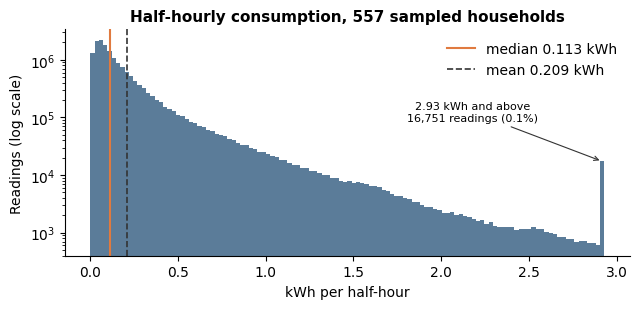

16,740,052 readings, mean 0.2087 kWh
Last bar: 16,751 readings at or above the 99.9th percentile (2.93 kWh), 0.10% of all readings


In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
upper = float(kwh.quantile(0.999))
counts, edges, _ = ax.hist(kwh.clip(upper=upper), bins=120, color=STD)
ax.set_yscale("log")
ax.axvline(kwh.median(), color=TOU, lw=1.5, label=f"median {kwh.median():.3f} kWh")
ax.axvline(kwh.mean(), color="#333", lw=1.2, ls="--", label=f"mean {kwh.mean():.3f} kWh")
# The last bar holds every reading above the 99.9th percentile, so it is not a peak in the data.
n_last = int((kwh >= upper).sum())  # readings clipped into the last bar (the bar itself is slightly taller)
ax.annotate(f"{upper:.2f} kWh and above\n{n_last:,} readings ({n_last / len(kwh):.1%})",
            xy=((edges[-1] + edges[-2]) / 2, counts[-1]), xytext=(edges[-1] - 0.75, counts[-1] * 5),
            ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", color="#333", lw=0.8))
ax.set_xlabel("kWh per half-hour")
ax.set_ylabel("Readings (log scale)")
ax.set_title(f"Half-hourly consumption, {len(sample_ids):,} sampled households")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT / "fig4_8_kwh_hist.png", dpi=200)
plt.show()

q = kwh.quantile([0.25, 0.5, 0.75])
report["Q1"] = round(float(q[0.25]), 3)
report["MEDIAN"] = round(float(q[0.5]), 3)
report["Q3"] = round(float(q[0.75]), 3)
print(f"{len(kwh):,} readings, mean {kwh.mean():.4f} kWh")
print(f"Last bar: {n_last:,} readings at or above the 99.9th percentile ({upper:.2f} kWh), "
      f"{n_last / len(kwh):.2%} of all readings")

## Step 7: Fig 4.7 Time-of-day load profile (London time)

Uses the hhblock layer: one row per complete household-day, columns `hh_0` to `hh_47`.

**Clock convention.** `tstp` is in GMT and marks the **end** of each half-hour measurement period (UK Data Service user guide, SN 7857, data tables). Column `hh_k` is the reading stamped `k x 30` minutes on that date, so `hh_0` is the half-hour that ended at 00:00. Two consequences:
- The profile is regrouped by **London clock time** (GMT in winter, GMT+1 in summer). Grouping by the GMT stamp would place every summer evening one hour early.
- Each value is labelled by the half-hour it *covers* (stamp minus 30 minutes), for example `19:00-19:30`.

The end-of-interval label comes from the documentation. The Kaggle data alone cannot confirm it; Step 8 shows what the data does confirm.

3,469,352 household-days from 112 hhblock files
Lowest half-hour:  04:00-04:30  0.113 kWh
Highest half-hour: 19:00-19:30  0.319 kWh  (2.83 x the lowest)
Half-hours above 0.3 kWh: 6, 18:00 to 21:00
Of these, inside the fixed 16:00-19:00 window: 2
For comparison, grouped by the GMT stamp instead: highest 0.321 kWh (stamp 19:00), 7 half-hours above 0.3 kWh


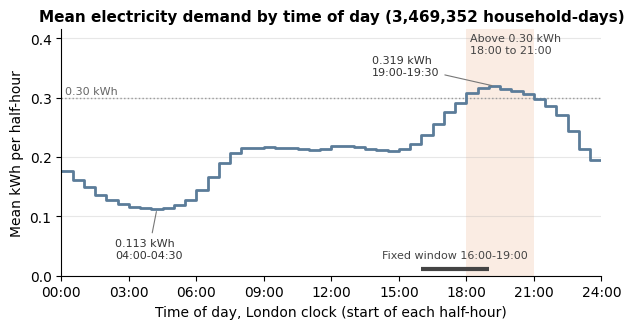

In [13]:
HH_COLS = [f"hh_{k}" for k in range(48)]
PEAK_LEVEL = 0.30        # kWh per half-hour: half-hours above this form the evening peak band
FIXED_WINDOW = (16, 19)  # fixed evening peak window of report Section 5.1, London hours


def interval_label(k):
    """Half-hour k (0 = 00:00-00:30) as 'HH:MM-HH:MM'."""
    a, b = k * 30, (k + 1) * 30 % 1440
    return f"{a // 60:02d}:{a % 60:02d}-{b // 60:02d}:{b % 60:02d}"


hh_files = sorted((dataset_dir / "hhblock_dataset").rglob("block_*.csv"))
if not hh_files:
    raise FileNotFoundError(f"No block_*.csv files under {dataset_dir / 'hhblock_dataset'}")
sum_by_day = count_by_day = None
n_household_days = 0
for path in hh_files:
    block_hh = pd.read_csv(path, usecols=["day"] + HH_COLS, na_values=["Null"])
    n_household_days += len(block_hh)
    s, c = block_hh.groupby("day")[HH_COLS].sum(), block_hh.groupby("day")[HH_COLS].count()
    sum_by_day = s if sum_by_day is None else sum_by_day.add(s, fill_value=0)
    count_by_day = c if count_by_day is None else count_by_day.add(c, fill_value=0)
del block_hh
print(f"{n_household_days:,} household-days from {len(hh_files)} hhblock files")

# Column hh_k of a row dated D is the reading stamped D + k x 30 min (GMT): the half-hour that ENDED then.
days = pd.to_datetime(sum_by_day.index)
stamp = pd.DatetimeIndex((days.values[:, None] + (np.arange(48) * 30).astype("timedelta64[m]")[None, :]).ravel())
start_london = (stamp - pd.Timedelta(minutes=30)).tz_localize("UTC").tz_convert("Europe/London")
slot = (start_london.hour * 2 + start_london.minute // 30).to_numpy()
profile = (np.bincount(slot, weights=sum_by_day.to_numpy().ravel(), minlength=48)
           / np.bincount(slot, weights=count_by_day.to_numpy().ravel(), minlength=48))
gmt_profile = sum_by_day.sum().to_numpy() / count_by_day.sum().to_numpy()  # grouped by the GMT stamp, for comparison

low_k, peak_k = int(profile.argmin()), int(profile.argmax())
above = np.flatnonzero(profile > PEAK_LEVEL)
assert (np.diff(above) == 1).all(), "half-hours above the peak level are not one contiguous block"
band_start, band_end = int(above[0]), int(above[-1]) + 1
in_window = int(((above >= FIXED_WINDOW[0] * 2) & (above < FIXED_WINDOW[1] * 2)).sum())

print(f"Lowest half-hour:  {interval_label(low_k)}  {profile[low_k]:.3f} kWh")
print(f"Highest half-hour: {interval_label(peak_k)}  {profile[peak_k]:.3f} kWh  ({profile[peak_k] / profile[low_k]:.2f} x the lowest)")
print(f"Half-hours above {PEAK_LEVEL} kWh: {len(above)}, {interval_label(band_start).split('-')[0]} to "
      f"{interval_label(band_end - 1).split('-')[1]}")
print(f"Of these, inside the fixed {FIXED_WINDOW[0]:02d}:00-{FIXED_WINDOW[1]:02d}:00 window: {in_window}")
print(f"For comparison, grouped by the GMT stamp instead: highest {gmt_profile.max():.3f} kWh "
      f"(stamp {interval_label(int(gmt_profile.argmax()) - 1).split('-')[1]}), "
      f"{int((gmt_profile > PEAK_LEVEL).sum())} half-hours above {PEAK_LEVEL} kWh")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
x = np.arange(49) / 2
ax.axvspan(band_start / 2, band_end / 2, color=TOU, alpha=0.14, lw=0)
ax.axhline(PEAK_LEVEL, color="#999", ls=":", lw=1)
ax.step(x, np.append(profile, profile[-1]), where="post", color=STD, lw=2)
top = profile.max() * 1.30
ax.set_ylim(0, top)
ax.set_xlim(0, 24)
ax.text(band_start / 2 + 0.15, top * 0.985,
        f"Above {PEAK_LEVEL:.2f} kWh\n{interval_label(band_start).split('-')[0]} to {interval_label(band_end - 1).split('-')[1]}",
        va="top", fontsize=8, color="#444")
ax.text(0.15, PEAK_LEVEL + 0.006, f"{PEAK_LEVEL:.2f} kWh", fontsize=8, color="#666")
ax.annotate(f"{profile[peak_k]:.3f} kWh\n{interval_label(peak_k)}",
            xy=(peak_k / 2 + 0.25, profile[peak_k]), xytext=(peak_k / 2 - 5.2, profile[peak_k] * 1.06),
            fontsize=8, color="#333", arrowprops={"arrowstyle": "-", "color": "#777", "lw": 0.8})
ax.annotate(f"{profile[low_k]:.3f} kWh\n{interval_label(low_k)}",
            xy=(low_k / 2 + 0.25, profile[low_k]), xytext=(low_k / 2 - 1.6, 0.03),
            fontsize=8, color="#333", arrowprops={"arrowstyle": "-", "color": "#777", "lw": 0.8})
ax.plot([FIXED_WINDOW[0], FIXED_WINDOW[1]], [0.012, 0.012], color="#444", lw=3, solid_capstyle="butt")
ax.text((FIXED_WINDOW[0] + FIXED_WINDOW[1]) / 2, 0.03,
        f"Fixed window {FIXED_WINDOW[0]:02d}:00-{FIXED_WINDOW[1]:02d}:00", ha="center", fontsize=8, color="#444")
ax.set_xticks(range(0, 25, 3), [f"{h:02d}:00" for h in range(0, 25, 3)])
ax.set_xlabel("Time of day, London clock (start of each half-hour)")
ax.set_ylabel("Mean kWh per half-hour")
ax.set_title(f"Mean electricity demand by time of day ({n_household_days:,} household-days)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "fig4_7_load_profile.png", dpi=200)
plt.show()

report["Load profile: lowest half-hour"] = f"{interval_label(low_k)}, {profile[low_k]:.3f} kWh"
report["Load profile: highest half-hour"] = (f"{interval_label(peak_k)}, {profile[peak_k]:.3f} kWh "
                                             f"({profile[peak_k] / profile[low_k]:.2f} x the lowest)")
report["Load profile: above 0.30 kWh"] = (f"{len(above)} half-hours, {interval_label(band_start).split('-')[0]} to "
                                          f"{interval_label(band_end - 1).split('-')[1]}; {in_window} inside "
                                          f"{FIXED_WINDOW[0]:02d}:00-{FIXED_WINDOW[1]:02d}:00")
report["Load profile: household-days"] = n_household_days

## Step 8: dToU price schedule, clock convention and day counts

Needs `Tariffs.xlsx` (High / Normal / Low for each half-hour of 2013), which is not in the Kaggle release. Section 0b of `01_eda_smart_meters.ipynb` downloads it to `~/.cache/london_datastore/`; run that once first.

**Trial day.** The UK Data Service guide defines a trial day as starting at **05:00 wall-clock time**, so a day here is 05:00 to 05:00 London time, not a calendar day. Day types:
- **Normal**: all 48 half-hours Normal.
- **High only** / **Low only**: at least one High (or Low) half-hour and none of the other.
- **High and Low**: both occur in the same trial day.

**Clock check.** The guide says the original files are GMT, but the schedule in the London Datastore release does not look like GMT (its event start times are the same clock hours in summer and winter). Rather than assume, the cell below measures when the ToU households' demand falls after a High event starts, relative to Std households, and how far that lags the schedule stamp. It does this twice: on the Kaggle stamp as it stands, and after converting each reading to the London clock time at the start of its half-hour. If the conversion is right, the response starts at offset 0 in both winter and summer.

Only the 2013 households that pass the coverage rule (`ok_2013`) enter the event study; the household-day counts are shown for them and for all households.

In [14]:
DTOU_FILE = Path.home() / ".cache" / "london_datastore" / "smartmeter-vqm0d" / "Tariffs.xlsx"
if not DTOU_FILE.exists():
    raise FileNotFoundError(f"{DTOU_FILE} not found. Run Section 0b of 01_eda_smart_meters.ipynb to download it.")
TRIAL_DAY_START = pd.Timedelta(hours=5)

schedule = pd.read_excel(DTOU_FILE, sheet_name="Sheet1").rename(columns={"TariffDateTime": "start", "Tariff": "level"})
assert len(schedule) == 365 * 48 and schedule["start"].is_unique, "schedule is not one row per half-hour of 2013"
assert set(schedule["level"]) == {"High", "Normal", "Low"}, set(schedule["level"])
schedule["trial_day"] = (schedule["start"] - TRIAL_DAY_START).dt.normalize()

by_day = schedule.groupby("trial_day").agg(half_hours=("level", "size"),
                                           high=("level", lambda s: (s == "High").any()),
                                           low=("level", lambda s: (s == "Low").any()))
partial = by_day[by_day["half_hours"] < 48]
full = by_day[by_day["half_hours"] == 48]  # trial days fully inside the schedule
day_type = pd.Series(np.select([full["high"] & full["low"], full["high"], full["low"]],
                               ["High and Low", "High only", "Low only"], "Normal"), index=full.index)
DAY_TYPES = ["Normal", "High only", "Low only", "High and Low"]
type_counts = day_type.value_counts().reindex(DAY_TYPES).fillna(0).astype(int)
print(f"Trial days (05:00 to 05:00) fully inside the 2013 schedule: {len(full)} "
      f"({full.index.min():%d %b %Y} to {full.index.max():%d %b %Y})")
print("Not counted, cut off by the ends of the schedule: "
      + ", ".join(f"{d:%d %b %Y} ({h} half-hours)" for d, h in partial["half_hours"].items()))
print(type_counts.to_string())
print(f"Days with at least one High half-hour: {int(full['high'].sum())}, with at least one Low: {int(full['low'].sum())}")
clock_change_days = [pd.Timestamp("2013-03-30"), pd.Timestamp("2013-10-26")]  # trial days that contain the clock change
print("Trial days containing a clock change: "
      + ", ".join(f"{d:%d %b} = {day_type[d]}" for d in clock_change_days))

report["Trial days 2013 (05:00 to 05:00)"] = (f"{len(full)} complete: " + ", ".join(f"{t} {n}" for t, n in type_counts.items())
                                              + f"; at least one High {int(full['high'].sum())}, at least one Low {int(full['low'].sum())}")

Trial days (05:00 to 05:00) fully inside the 2013 schedule: 364 (01 Jan 2013 to 30 Dec 2013)
Not counted, cut off by the ends of the schedule: 31 Dec 2012 (10 half-hours), 31 Dec 2013 (38 half-hours)
Normal          244
High only        45
Low only         50
High and Low     25
Days with at least one High half-hour: 70, with at least one Low: 75
Trial days containing a clock change: 30 Mar = Normal, 26 Oct = Normal


In [15]:
coverage_flags = pd.read_csv(OUT / "household_coverage_flags.csv")  # written in Step 4
tariff_of = households.set_index("LCLid")["stdorToU"]
ok_2013_ids = set(coverage_flags.loc[coverage_flags["ok_2013"], "LCLid"])
GRID = pd.Timedelta(minutes=30)

# One pass over the 112 half-hourly files. Each distinct timestamp string is parsed once per file (about 17,500
# of them) and mapped back to the rows, which is much faster than parsing every row.
hd_parts, ts_parts, off_grid, off_grid_null = [], [], 0, 0
for i, path in enumerate(block_files, 1):
    df = pd.read_csv(path, usecols=["LCLid", "tstp", "energy(kWh/hh)"], na_values=["Null"]).rename(columns={"energy(kWh/hh)": "kwh"})
    codes, uniq = pd.factorize(df["tstp"])
    stamp_gmt = pd.to_datetime(uniq)  # end of the half-hour, GMT
    start_london_naive = (stamp_gmt - GRID).tz_localize("UTC").tz_convert("Europe/London").tz_localize(None)
    trial_day = (start_london_naive - TRIAL_DAY_START).normalize()
    on_grid = ((stamp_gmt.minute % 30 == 0) & (stamp_gmt.second == 0))[codes]
    has_value = df["kwh"].notna().to_numpy()
    off_grid += int((~on_grid).sum())
    off_grid_null += int((~on_grid & ~has_value).sum())

    # Readings per household and trial day (complete trial days only).
    trial_row = trial_day[codes]
    keep = on_grid & has_value & np.asarray((trial_row >= full.index.min()) & (trial_row <= full.index.max()))
    hd_parts.append(pd.DataFrame({"LCLid": df["LCLid"].to_numpy()[keep], "trial_day": trial_row[keep]})
                    .groupby(["LCLid", "trial_day"]).size().rename("n").reset_index())

    # Mean demand per half-hour for the 2013-qualifying households, by tariff group.
    sel = on_grid & df["LCLid"].isin(ok_2013_ids).to_numpy()
    grouped = (pd.DataFrame({"code": codes[sel], "g": df["LCLid"][sel].map(tariff_of).to_numpy(), "kwh": df["kwh"].to_numpy()[sel]})
               .groupby(["code", "g"])["kwh"].agg(["sum", "count"]).reset_index())
    grouped["raw"] = stamp_gmt[grouped["code"].to_numpy()]
    grouped["local"] = start_london_naive[grouped["code"].to_numpy()]
    ts_parts.append(grouped)
    if i % 16 == 0 or i == len(block_files):
        print(f"  read {i}/{len(block_files)} block files")
print(f"Readings stamped off the half-hour grid (ignored): {off_grid:,}, of which {off_grid_null:,} have a Null value")

# --- Household-days per trial-day type -------------------------------------------------------------------
hd = pd.concat(hd_parts, ignore_index=True)
hd["day_type"] = hd["trial_day"].map(day_type)
hd["tariff"] = hd["LCLid"].map(tariff_of)
hd["usable"] = hd["n"] >= USABLE_READINGS
hd["in_2013_sample"] = hd["LCLid"].isin(ok_2013_ids)


def household_days(frame, label):
    tab = (frame.groupby(["tariff", "day_type"]).size().unstack("day_type").reindex(columns=DAY_TYPES).fillna(0).astype(int))
    tab.loc["Total"] = tab.sum()
    tab["All types"] = tab.sum(axis=1)
    print(f"\n{label}")
    print(tab.to_string())
    return tab


print(f"\nHousehold-days per trial-day type (a household-day = one household on one 05:00-05:00 day; usable = at least "
      f"{USABLE_READINGS} of its readings)")
hd_ok = household_days(hd[hd["in_2013_sample"] & hd["usable"]], "2013-qualifying households (ok_2013), usable household-days")
hd_all = household_days(hd[hd["usable"]], "All households, usable household-days")
n_any = int(hd["in_2013_sample"].sum())
print(f"\n2013-qualifying households, any reading at all: {n_any:,} household-days "
      f"({int((hd['in_2013_sample'] & hd['usable']).sum()):,} usable)")

report["Household-days on Normal days (ok_2013, usable)"] = (
    f"{hd_ok.loc['Total', 'Normal']:,} (Std {hd_ok.loc['Std', 'Normal']:,}, ToU {hd_ok.loc['ToU', 'Normal']:,}); "
    f"High only {hd_ok.loc['Total', 'High only']:,}, Low only {hd_ok.loc['Total', 'Low only']:,}, "
    f"High and Low {hd_ok.loc['Total', 'High and Low']:,}")
report["Household-days on Normal days (all households, usable)"] = f"{hd_all.loc['Total', 'Normal']:,} of {hd_all.loc['Total', 'All types']:,}"

# --- Clock check: when does ToU demand fall after a High event starts? -----------------------------------
def log_ratio(key):
    tot = pd.concat(ts_parts).groupby([key, "g"])[["sum", "count"]].sum()
    mean = (tot["sum"] / tot["count"]).unstack("g")
    return np.log(mean["ToU"] / mean["Std"])


ratio_views = {"Kaggle stamp as it stands": log_ratio("raw"), "London start of half-hour": log_ratio("local")}
events = schedule.assign(run=(schedule["level"] != schedule["level"].shift()).cumsum())
events = (events.groupby("run").agg(level=("level", "first"), start=("start", "min"), n=("level", "size"))
          .query("level != 'Normal'"))
events = events[events["n"].between(4, 12)]  # 2 to 6 hour events
events["summer"] = [ts.tz_localize("Europe/London", ambiguous=True, nonexistent="shift_forward").dst() != pd.Timedelta(0)
                    for ts in events["start"]]
OFFSETS = list(range(-3, 5))
ONSET_LEVEL = 0.04  # a move of this size in log(ToU / Std) counts as the response


def response(series, level, summer):
    starts = events.loc[(events["level"] == level) & (events["summer"] == summer), "start"]
    rows = []
    for s0 in starts:
        base = series.reindex(s0 + pd.to_timedelta(np.arange(-8, -3) * 30, unit="m")).mean()
        rows.append([series.get(s0 + GRID * k, np.nan) - base for k in OFFSETS])
    return len(starts), pd.DataFrame(rows, columns=OFFSETS).mean()


print("\nChange in log(ToU / Std demand) from the 2 hours before the event start, mean over events")
print("(columns: half-hours after the schedule stamp; the response starts where the size passes "
      f"{ONSET_LEVEL})")
onsets = {}


def fmt_onset(k):
    return "none" if k is None else f"{k:+d}"


for view, series in ratio_views.items():
    for level, sign in [("High", -1), ("Low", 1)]:
        for summer in [False, True]:
            n_ev, resp = response(series, level, summer)
            onset = next((k for k in OFFSETS if sign * resp[k] >= ONSET_LEVEL), None)
            onsets[(view, level, summer)] = onset
            print(f"{view:<27} {level:<4} {'summer' if summer else 'winter'} ({n_ev:>2} events)  "
                  + " ".join(f"{k:+d}:{resp[k]:+.3f}" for k in OFFSETS) + f"   onset {fmt_onset(onset)}")

as_is = {(lvl, sm): onsets[("Kaggle stamp as it stands", lvl, sm)] for lvl in ["High", "Low"] for sm in [False, True]}
london = {(lvl, sm): onsets[("London start of half-hour", lvl, sm)] for lvl in ["High", "Low"] for sm in [False, True]}
report["Clock check (response onset, half-hours after schedule stamp)"] = (
    "Kaggle stamp as is: " + ", ".join(f"{lvl} {'summer' if sm else 'winter'} {fmt_onset(o)}" for (lvl, sm), o in as_is.items())
    + "; London start of half-hour: " + ", ".join(f"{lvl} {'summer' if sm else 'winter'} {fmt_onset(o)}" for (lvl, sm), o in london.items()))

  read 16/112 block files


  read 32/112 block files


  read 48/112 block files


  read 64/112 block files


  read 80/112 block files


  read 96/112 block files


  read 112/112 block files
Readings stamped off the half-hour grid (ignored): 5,560, of which 5,560 have a Null value

Household-days per trial-day type (a household-day = one household on one 05:00-05:00 day; usable = at least 44 of its readings)



2013-qualifying households (ok_2013), usable household-days
day_type   Normal  High only  Low only  High and Low  All types
tariff                                                         
Std       1027751     190590    210155        105100    1533596
ToU        261847      48560     53570         26790     390767
Total     1289598     239150    263725        131890    1924363



All households, usable household-days
day_type   Normal  High only  Low only  High and Low  All types
tariff                                                         
Std       1031071     191242    210802        105464    1538579
ToU        262631      48703     53726         26884     391944
Total     1293702     239945    264528        132348    1930523

2013-qualifying households, any reading at all: 1,927,326 household-days (1,924,363 usable)



Change in log(ToU / Std demand) from the 2 hours before the event start, mean over events
(columns: half-hours after the schedule stamp; the response starts where the size passes 0.04)
Kaggle stamp as it stands   High winter (34 events)  -3:+0.008 -2:+0.007 -1:+0.011 +0:+0.003 +1:-0.073 +2:-0.102 +3:-0.099 +4:-0.092   onset +1
Kaggle stamp as it stands   High summer (27 events)  -3:+0.009 -2:-0.013 -1:-0.068 +0:-0.073 +1:-0.064 +2:-0.083 +3:-0.090 +4:-0.084   onset -1
Kaggle stamp as it stands   Low  winter (28 events)  -3:+0.003 -2:+0.014 -1:+0.022 +0:+0.021 +1:+0.120 +2:+0.037 +3:+0.031 +4:+0.033   onset +1
Kaggle stamp as it stands   Low  summer (25 events)  -3:+0.005 -2:+0.013 -1:+0.158 +0:+0.155 +1:+0.154 +2:+0.117 +3:+0.098 +4:+0.096   onset -1
London start of half-hour   High winter (34 events)  -3:+0.005 -2:+0.009 -1:+0.002 +0:-0.074 +1:-0.104 +2:-0.100 +3:-0.093 +4:-0.092   onset +0
London start of half-hour   High summer (27 events)  -3:+0.002 -2:+0.013 -1:-0.009 +0:-0.064 +

## Step 9: Supporting checks

Short checks behind statements in Section 4 that no earlier step prints. They change no figure and no count above.

- **Daily layer:** duplicates, the first and last day of each household, what the other incomplete days look like, and how many households stop early.
- **Clock-change days:** on a London-time daily layer, the day of a clock change would have 46 or 50 readings. Counting 48 fits a continuous GMT clock. The second check moves the average daily profile across each change; the two-week windows also contain the seasonal change in daylight, so read the shift as approximate. Step 8 is the main evidence for the clock.
- **ACORN:** the groups compared pairwise, the dToU share by ACORN letter, and the group test repeated on the households that pass the 2013 coverage rule.

In [16]:
# --- Daily layer (reloaded: Step 4 freed it) ---------------------------------------------------------------
if daily_csv.exists():
    chk = pd.read_csv(daily_csv, usecols=cols)
else:
    chk = pd.concat([pd.read_csv(f, usecols=cols) for f in sorted((dataset_dir / "daily_dataset").rglob("block_*.csv"))],
                    ignore_index=True)
chk["day"] = pd.to_datetime(chk["day"])
chk = chk.sort_values(["LCLid", "day"], ignore_index=True)
chk["incomplete"] = chk["energy_count"] < 48

n_dup = int(chk.duplicated(["LCLid", "day"]).sum())
print(f"Duplicate (household, day) rows: {n_dup:,}; energy_count above 48: {int((chk['energy_count'] > 48).sum()):,} "
      f"(maximum {int(chk['energy_count'].max())})")

first_rows = chk.groupby("LCLid").head(1)
last_rows = chk.groupby("LCLid").tail(1)
inner = chk.drop(index=first_rows.index.union(last_rows.index))
inner_inc = inner[inner["incomplete"]]
n_47 = int((inner_inc["energy_count"] == 47).sum())
n_half = int((inner_inc["energy_count"] <= 24).sum())
print(f"Households whose first day is incomplete: {first_rows['incomplete'].mean():.1%}; last day: {last_rows['incomplete'].mean():.1%}")
print(f"Incomplete days that are not a first or last day: {len(inner_inc):,}; "
      f"exactly 47 readings {n_47:,} ({n_47 / len(inner_inc):.1%}), 24 or fewer {n_half:,} ({n_half / len(inner_inc):.1%})")
last_date = chk["day"].max()
n_stop = int((chk.groupby("LCLid")["day"].max() < last_date).sum())
print(f"Households whose last day is before {last_date:%d %b %Y}: {n_stop:,} of {chk['LCLid'].nunique():,}")

# --- Clock-change days -------------------------------------------------------------------------------------
CLOCK_CHANGES = [("spring", "2012-03-25"), ("autumn", "2012-10-28"), ("spring", "2013-03-31"), ("autumn", "2013-10-27")]
print("\nReadings per household-day on the days the clocks changed (London time would give 46 in spring, 50 in autumn):")
for kind, d in CLOCK_CHANGES:
    n_read = chk.loc[chk["day"] == d, "energy_count"]
    print(f"  {d} ({kind}): {len(n_read):,} household-days, {(n_read == 48).mean():.1%} have 48 readings, "
          f"{n_read.isin([46, 50]).mean():.1%} have 46 or 50")

S, C = sum_by_day.copy(), count_by_day.copy()  # from Step 7, one row per date
S.index, C.index = pd.to_datetime(S.index), pd.to_datetime(C.index)


def window_profile(start, end):
    m = (S.index >= start) & (S.index <= end)
    return S[m].sum().to_numpy() / C[m].sum().to_numpy()


def best_shift(before, after, max_shift=6):
    b, a = before - before.mean(), after - after.mean()
    corr = {k: float(np.corrcoef(b, np.roll(a, -k))[0, 1]) for k in range(-max_shift, max_shift + 1)}
    return max(corr, key=corr.get), corr


print("\nShift of the average daily profile (GMT stamps) across each change, two weeks either side, in half-hours:")
print("  a GMT clock predicts -2 in spring and +2 in autumn; a London clock predicts 0")
for kind, d in CLOCK_CHANGES:
    t = pd.Timestamp(d)
    before = window_profile(t - pd.Timedelta(days=14), t - pd.Timedelta(days=1))
    after = window_profile(t + pd.Timedelta(days=1), t + pd.Timedelta(days=14))
    k, corr = best_shift(before, after)
    print(f"  {d} ({kind}): best shift {k:+d} (correlation {corr[k]:.3f}; with no shift {corr[0]:.3f})")

# --- ACORN ---------------------------------------------------------------------------------------------------
def chi2_stat(tab):
    tab = np.asarray(tab, dtype=float)
    expected = np.outer(tab.sum(axis=1), tab.sum(axis=0)) / tab.sum()
    return float(((tab - expected) ** 2 / expected).sum())


print("\nGroups compared in pairs (chi-square, df = 1; household-level, so read with the block-level result in Step 5):")
for a, b in [("Affluent", "Comfortable"), ("Affluent", "Adversity"), ("Comfortable", "Adversity")]:
    c2 = chi2_stat(table.loc[[a, b]])
    print(f"  {a} vs {b}: chi2 = {c2:.2f}, p = {math.erfc(math.sqrt(c2 / 2)):.1e}")

letters = (classified.groupby(["Acorn_grouped", "Acorn"])["stdorToU"]
           .agg(households="size", tou=lambda s: int((s == "ToU").sum())).reset_index())
letters["tou_share_pct"] = (letters["tou"] / letters["households"] * 100).round(1)
letters = letters.sort_values("tou_share_pct")
print("\ndToU share by ACORN letter, lowest to highest:")
print(letters.to_string(index=False))

subset = classified[classified["LCLid"].isin(ok_2013_ids)]
tab_subset = pd.crosstab(subset["Acorn_grouped"], subset["stdorToU"]).reindex(GROUPS)
c2_subset = chi2_stat(tab_subset)
share_subset = tab_subset["ToU"] / tab_subset.sum(axis=1) * 100
print(f"\nSame test on the {len(subset):,} classified households that pass the 2013 coverage rule: "
      + ", ".join(f"{g} {share_subset[g]:.1f}%" for g in GROUPS)
      + f"; chi2 = {c2_subset:.2f}, p = {math.exp(-c2_subset / 2):.2e}")

report["Daily layer: duplicates"] = n_dup
report["Daily layer: first / last day incomplete"] = f"{first_rows['incomplete'].mean():.1%} / {last_rows['incomplete'].mean():.1%} of households"
report["Daily layer: other incomplete days"] = f"{len(inner_inc):,}; {n_47:,} have exactly 47 readings, {n_half:,} have 24 or fewer"
report["Households stopping before the last date"] = n_stop
report["ACORN pairwise (chi2, df = 1)"] = "; ".join(
    f"{a} vs {b} {chi2_stat(table.loc[[a, b]]):.2f}" for a, b in [("Affluent", "Comfortable"), ("Affluent", "Adversity"), ("Comfortable", "Adversity")])
report["ACORN letters: lowest / highest dToU share"] = (
    f"{letters.iloc[0]['Acorn']} {letters.iloc[0]['tou_share_pct']}% (n = {letters.iloc[0]['households']}), "
    f"{letters.iloc[-1]['Acorn']} {letters.iloc[-1]['tou_share_pct']}% (n = {letters.iloc[-1]['households']})")
report["ACORN test on ok_2013 households"] = (", ".join(f"{g} {share_subset[g]:.1f}%" for g in GROUPS)
                                              + f"; chi2 = {c2_subset:.2f}, p = {math.exp(-c2_subset / 2):.2e}")
del chk, first_rows, last_rows, inner, inner_inc, S, C

Duplicate (household, day) rows: 0; energy_count above 48: 0 (maximum 48)


Households whose first day is incomplete: 100.0%; last day: 98.0%
Incomplete days that are not a first or last day: 30,063; exactly 47 readings 21,035 (70.0%), 24 or fewer 5,918 (19.7%)


Households whose last day is before 28 Feb 2014: 579 of 5,566

Readings per household-day on the days the clocks changed (London time would give 46 in spring, 50 in autumn):
  2012-03-25 (spring): 1,189 household-days, 99.7% have 48 readings, 0.0% have 46 or 50
  2012-10-28 (autumn): 5,520 household-days, 99.7% have 48 readings, 0.0% have 46 or 50
  2013-03-31 (spring): 5,410 household-days, 99.8% have 48 readings, 0.0% have 46 or 50
  2013-10-27 (autumn): 5,194 household-days, 99.7% have 48 readings, 0.0% have 46 or 50

Shift of the average daily profile (GMT stamps) across each change, two weeks either side, in half-hours:
  a GMT clock predicts -2 in spring and +2 in autumn; a London clock predicts 0
  2012-03-25 (spring): best shift -1 (correlation 0.902; with no shift 0.893)
  2012-10-28 (autumn): best shift +2 (correlation 0.987; with no shift 0.942)
  2013-03-31 (spring): best shift -1 (correlation 0.985; with no shift 0.958)
  2013-10-27 (autumn): best shift +1 (correlation 0.9

## Step 10: Numbers for the report

Copy these into the yellow blanks. The same text is saved to `outputs/numbers_for_report.txt`.

In [17]:
lines = [f"{k:<30} {v:,}" if isinstance(v, int) else f"{k:<30} {v}" for k, v in report.items()]
text = "\n".join(lines)
print(text)
(OUT / "numbers_for_report.txt").write_text(text + "\n", encoding="utf-8")
print(f"\nFigures and numbers saved in {OUT.resolve()}")

X  (Std, both 2012 and 2013)   3,356
Y  (ToU, both 2012 and 2013)   835
X2 (Std, 2013)                 4,387
Y2 (ToU, 2013)                 1,111
Usable-month rule (2012)       >= 90% of calendar days usable (>= 44/48 readings); >= 6 such months
Sensitivity (2012 month)       usable month at >= 50% of days instead: 3,737 Std, 951 ToU with both years
Short 2013 periods             262 Std and 66 ToU households pass the 2013 rule with a recorded 2013 period under 300 days (shortest 10 days)
chi-square check               Affluent 22.4% ToU, Comfortable 21.4% ToU, Adversity 16.4% ToU; household-level chi2 = 23.95, df = 2, p = 6.29e-06, Cramer's V = 0.066
block-level test               109 blocks, mean block dToU share Affluent 21.9%, Comfortable 21.5%, Adversity 16.4%; permutation p = 0.267 (three groups), 0.107 (Adversity vs others)
ACORN unclassified (excluded)  51
Q1                             0.056
MEDIAN                         0.113
Q3                             0.237
Load profile